# Bayes Theorem
Bayes’ Theorem is a fundamental rule in probability theory that describes how to update the probability of a hypothesis when new evidence is introduced. It’s the mathematical backbone of Naive Bayes classifiers and many other probabilistic models.


<img src="https://static.vecteezy.com/system/resources/previews/026/586/263/original/bayes-theorem-probability-theory-statistics-illustration-infographic-vector.jpg" width=500px height=300px>

# Naive-Bayes
Naive Bayes is a simple yet powerful probabilistic classification algorithm based on Bayes’ Theorem, widely used in text classification tasks like spam filtering, sentiment analysis, and document categorization. It is called “naive” because it assumes all features are independent of each other, which is rarely true in practice but still works surprisingly well.


<img src="https://www.codespeedy.com/wp-content/uploads/2019/06/Formula-of-Naive-Bayes-theory.png" width=500px height=300px>

**Sentiment analysis with the help of naive bayes algorithm**

In [43]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
df=pd.read_csv(r"C:\Users\Sonu\OneDrive\Desktop\machine learning\Naive Bayes\IMDB Dataset.csv")

In [44]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**first of all we do Text Precprocessing**
1. Remove html tags
2. Remove special character
3. convert everything to lowercase
4. Remove stop words
5. **vectorization**(we use (BOW) bag of word here you also use other technique)

In [45]:
# one review
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [46]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [47]:
df['sentiment'].replace({'positive':1,'negative':0},inplace=True)

C:\Users\Sonu\AppData\Local\Temp\ipykernel_22132\4240984564.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'].replace({'positive':1,'negative':0},inplace=True)


In [48]:
df.head

<bound method NDFrame.head of                                                   review  sentiment
0      One of the other reviewers has mentioned that ...          1
1      A wonderful little production. <br /><br />The...          1
2      I thought this was a wonderful way to spend ti...          1
3      Basically there's a family where a little boy ...          0
4      Petter Mattei's "Love in the Time of Money" is...          1
...                                                  ...        ...
49995  I thought this movie did a down right good job...          1
49996  Bad plot, bad dialogue, bad acting, idiotic di...          0
49997  I am a Catholic taught in parochial elementary...          0
49998  I'm going to have to disagree with the previou...          0
49999  No one expects the Star Trek movies to be high...          0

[50000 rows x 2 columns]>

In [49]:
import re
def clean_html(text):
    clean=re.compile('<.*?>')
    return re.sub(clean,'',text)

In [50]:
df['review']=df['review'].apply(clean_html)


In [51]:
# convert everything to lowercase
def convert_lower(text):
    return text.lower()
df['review']=df['review'].apply(convert_lower)

In [52]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


In [53]:
# function to remove special characters
def remove_special(text):
    x=''
    for i in text:
        if i.isalnum():
            x+=i
        else:
            x+=' '
    return x
df['review']=df['review'].apply(remove_special)

In [54]:
# now, we remove stop words
# nltk.download('stopwords')
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [55]:
# function for remove stopwords
def remove_stopwords(text):
    x=[]
    stop_words=set(stopwords.words('english'))
    for i in text.split():
        if i not in stop_words:
            x.append(i)
    return x

In [56]:
df['review']=df['review'].apply(remove_stopwords)

In [57]:
df.head

<bound method NDFrame.head of                                                   review  sentiment
0      [one, reviewers, mentioned, watching, 1, oz, e...          1
1      [wonderful, little, production, filming, techn...          1
2      [thought, wonderful, way, spend, time, hot, su...          1
3      [basically, family, little, boy, jake, thinks,...          0
4      [petter, mattei, love, time, money, visually, ...          1
...                                                  ...        ...
49995  [thought, movie, right, good, job, creative, o...          1
49996  [bad, plot, bad, dialogue, bad, acting, idioti...          0
49997  [catholic, taught, parochial, elementary, scho...          0
49998  [going, disagree, previous, comment, side, mal...          0
49999  [one, expects, star, trek, movies, high, art, ...          0

[50000 rows x 2 columns]>

In [58]:
# now, we perform steeming(words reduces to root form)

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [60]:
y=[]
def stem_words(text):
    for i in text:
        y.append(ps.stem(i))
    z=y[:]
    y.clear()
    return z

In [61]:
df['review']=df['review'].apply(stem_words)

In [62]:
df.head()

,review,sentiment
0,"[one, review, mention, watch, 1, oz, episod, h...",1
1,"[wonder, littl, product, film, techniqu, unass...",1
2,"[thought, wonder, way, spend, time, hot, summe...",1
3,"[basic, famili, littl, boy, jake, think, zombi...",0
4,"[petter, mattei, love, time, money, visual, st...",1


In [63]:
# join back (convert the list of strings to a single string)
def join_back(list_input):
    return " ".join(list_input)

df['review']=df['review'].apply(join_back)

In [64]:
df.sample(2)

,review,sentiment
1499,start movi dark comedi would say fannn tastic ...,0
38160,magician wonder ride start finish thank larg p...,1


In [ ]:
x=df.iloc[:,0].values
y=df.iloc[:,-1].values

In [ ]:
print(x.shape)
print(y.shape)

(50000,)
(50000,)


In [71]:
# vectorization (convert text data to numerical data)
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=3000)
X=cv.fit_transform(x).toarray()

In [72]:
X[0].mean()

np.float64(0.04466666666666667)

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [76]:
print(x_train.shape)
print(x_test.shape)

(40000, 3000)
(10000, 3000)


In [77]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
GNB=GaussianNB()
MNB=MultinomialNB()
BNB=BernoulliNB()

In [78]:
GNB.fit(x_train,y_train)
MNB.fit(x_train,y_train)
BNB.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[19980.,20020.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 197.,2684., 341.,..., 338., 433., 113.], [ 159.,2647., 301.,..., 105., 168., 109.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 3000)","[[-4.61,-2.01,-4.07,...,-4.08,-3.83,-5.17], [-4.83,-2.02,-4.19,...,-5.24,-4.77,-5.2 ]]"


In [79]:
y_pred_GNB=GNB.predict(x_test)
y_pred_MNB=MNB.predict(x_test)
y_pred_BNB=BNB.predict(x_test)

In [80]:
from sklearn .metrics import accuracy_score
print("Gaussian",accuracy_score(y_test,y_pred_GNB))
print("Multinomial",accuracy_score(y_test,y_pred_MNB))
print("Bernaulli",accuracy_score(y_test,y_pred_BNB))

Gaussian 0.7465
Multinomial 0.846
Bernaulli 0.849


*This is genral naive bayes algorithm*
**Now, we study about types of naive baise**
1. Gaussian
2. categorical
3. Bernoulli
4. Multinomial
5. complement

# How naive bayes handles numerical data
Naive Bayes can handle numerical data by assuming that each numeric feature follows a probability distribution (most commonly Gaussian/normal), then using Bayes’ Theorem to compute class probabilities. This approach is called Gaussian Naive Bayes

<img src="https://thf.bing.com/th/id/R.8bd70c2238bf27f5859845fe85046834?rik=VW%2bJWYtwVlL9bw&riu=http%3a%2f%2fbuiltin.com%2fsites%2fwww.builtin.com%2ffiles%2fstyles%2fckeditor_optimize%2fpublic%2finline-images%2f7_gaussian-naive-bayes.jpg&ehk=qd%2biZ8RKBIHMj%2fCEf%2bg0%2btRLQsbzgp09qxuR9EmpdbQ%3d&risl=&pid=ImgRaw&r=0" width=600px height=400px>

<img src="https://files.codingninjas.in/article_images/gaussian-naive-bayes-3-1642161104.webp" width=400px height=300px>

In [82]:
import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
data=pd.read_csv(r"C:\Users\Sonu\OneDrive\Desktop\machine learning\Naive Bayes\weather.csv")

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [88]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='temp_max', ylabel='Count'>

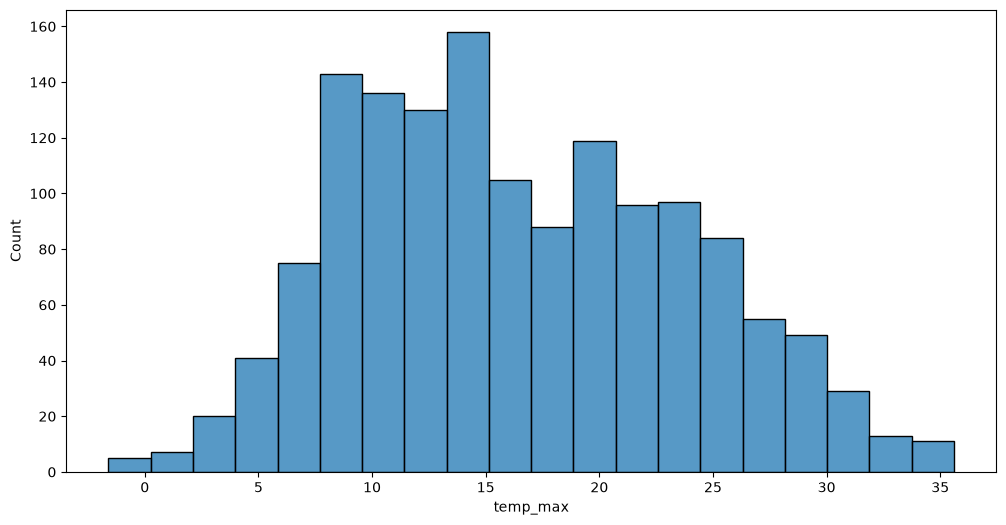

In [89]:
plt.figure(figsize=(12,6))
sns.histplot(data=data,x=data.temp_max,bins=20)

<Axes: xlabel='temp_min', ylabel='Count'>

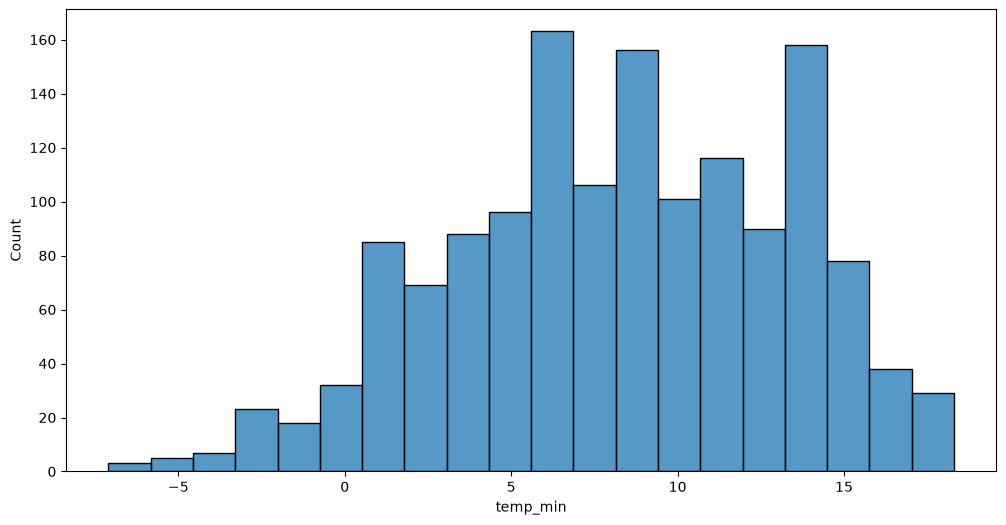

In [90]:
plt.figure(figsize=(12,6))
sns.histplot(data=data,x=data.temp_min,bins=20)

In [96]:
data.head()

,date,precipitation,temp_max,temp_min,wind,weather,month,day
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,1,1
1,2012-01-02,10.9,10.6,2.8,4.5,rain,1,2
2,2012-01-03,0.8,11.7,7.2,2.3,rain,1,3
3,2012-01-04,20.3,12.2,5.6,4.7,rain,1,4
4,2012-01-05,1.3,8.9,2.8,6.1,rain,1,5


In [94]:
# column named 'date' is object type
data['date'] = pd.to_datetime(data['date'])

In [95]:
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day


In [100]:
data.drop("date",axis=1,inplace=True)

In [101]:
data.head()

,precipitation,temp_max,temp_min,wind,weather,month,day
0,0.0,12.8,5.0,4.7,drizzle,1,1
1,10.9,10.6,2.8,4.5,rain,1,2
2,0.8,11.7,7.2,2.3,rain,1,3
3,20.3,12.2,5.6,4.7,rain,1,4
4,1.3,8.9,2.8,6.1,rain,1,5


In [102]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [103]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['weather']=le.fit_transform(data['weather'])

In [104]:
data.head()

,precipitation,temp_max,temp_min,wind,weather,month,day
0,0.0,12.8,5.0,4.7,0,1,1
1,10.9,10.6,2.8,4.5,2,1,2
2,0.8,11.7,7.2,2.3,2,1,3
3,20.3,12.2,5.6,4.7,2,1,4
4,1.3,8.9,2.8,6.1,2,1,5


In [ ]:
y1=data['weather']
data.drop('weather',axis=1,inplace=True)
x1=data.iloc[:,:]

In [113]:
print(x1)

      precipitation  temp_max  temp_min  wind  month  day
0               0.0      12.8       5.0   4.7      1    1
1              10.9      10.6       2.8   4.5      1    2
2               0.8      11.7       7.2   2.3      1    3
3              20.3      12.2       5.6   4.7      1    4
4               1.3       8.9       2.8   6.1      1    5
...             ...       ...       ...   ...    ...  ...
1456            8.6       4.4       1.7   2.9     12   27
1457            1.5       5.0       1.7   1.3     12   28
1458            0.0       7.2       0.6   2.6     12   29
1459            0.0       5.6      -1.0   3.4     12   30
1460            0.0       5.6      -2.1   3.5     12   31

[1461 rows x 6 columns]


In [ ]:
print(y1)

0       0
1       2
2       2
3       2
4       2
       ..
1456    2
1457    2
1458    1
1459    4
1460    4
Name: weather, Length: 1461, dtype: int64


In [114]:
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2)

In [115]:
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

In [116]:
accuracy_score=accuracy_score(y_test,y_pred)
print(accuracy_score)

0.8703071672354948


In [117]:
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, zero_division=1)

In [118]:
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Confusion Matrix:
[[  2   0   0   0   9]
 [  0   0   0   0  14]
 [  0   0 118   2  11]
 [  0   0   2   1   0]
 [  0   0   0   0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        11
           1       1.00      0.00      0.00        14
           2       0.98      0.90      0.94       131
           3       0.33      0.33      0.33         3
           4       0.80      1.00      0.89       134

    accuracy                           0.87       293
   macro avg       0.82      0.48      0.49       293
weighted avg       0.89      0.87      0.84       293



**In gaussian naive bayes we never  use laplace smoothing because here never probablity bercome zero** 

# Multinomial naive bayes
Multinomial Naive Bayes is a variant of Naive Bayes designed for discrete data like word counts or frequencies. It’s widely used in text classification tasks such as spam detection, sentiment analysis, and document categorization because it models how often words appear in each class.
There all features have discrete values
Like, in text data when we apply count bag-of-word(BOW)

# Categorical naive bayes 
we apply this when we have all categorical columns
here,we do laplace smoothing 

<img src="https://towardsdatascience.com/wp-content/uploads/2020/11/1pvtiVc9Sqs7NJ23u0KHOpg.png" width=500px height=200px>


"k is total no of unique category and alpha is hyperparametr default value is 1"